# Librerías

In [1]:
!pip install pygad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.3/218.3 kB 1.3 MB/s eta 0:00:00


In [ ]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

# Funciones del programa

In [ ]:
def f(x, y):
    return x**2 + 2*y**2 - 0.3*np.cos(3*np.pi*x) - 0.4*np.cos(4*np.pi*y) + 0.7

def binario_a_float(array, bits=16, valor_maximo=5.0, valor_minimo=-5.0):
    escala = (valor_maximo - valor_minimo) / (2**bits - 1)
    string_binario = "".join(str(int(b)) for b in array)
    decimal = int(string_binario, 2)
    return valor_minimo + (decimal * escala)

def funcion_de_adaptacion(instancia_ga, solucion, indice_solucion):
    binario_x = solucion[:16]
    binario_y = solucion[16:]

    x = binario_a_float(binario_x)
    y = binario_a_float(binario_y)

    funcion = f(x, y)
    return -funcion

def ejecucion_simulacion(numero_de_simulaciones=30, tipo_de_escalado=None, conversion_de_ventana=None, **kwargs):
    historial_de_mejores = []
    historial_de_promedios = []

    for i in range(numero_de_simulaciones):
        media_local = []

        def llamada_generaciones(instancia):
            poblacion_fitness = instancia.last_generation_fitness
            if tipo_de_escalado == "window" and conversion_de_ventana is not None:
                pass
            media_local.append(np.mean(poblacion_fitness))

        carga_genetica = pygad.GA(
            num_generations=100,
            sol_per_pop=100,
            num_parents_mating=20,
            fitness_func=funcion_de_adaptacion,

            gene_type=int,
            gene_space=[0, 1],
            mutation_by_replacement=True,
            random_mutation_min_val=0,
            random_mutation_max_val=2,

            num_genes=32,
            on_generation=llamada_generaciones,
            **kwargs
        )
        carga_genetica.run()

        historial_de_mejores.append(carga_genetica.best_solutions_fitness)
        historial_de_promedios.append(media_local)

    media_mejores = np.mean(historial_de_mejores, axis=0)
    media_promedios = np.mean(historial_de_promedios, axis=0)

    return media_mejores, media_promedios

#Simulación AG Simple

Ejecutando A.G. Simple...
Simulaciones completadas exitosamente. Generando gráfica...


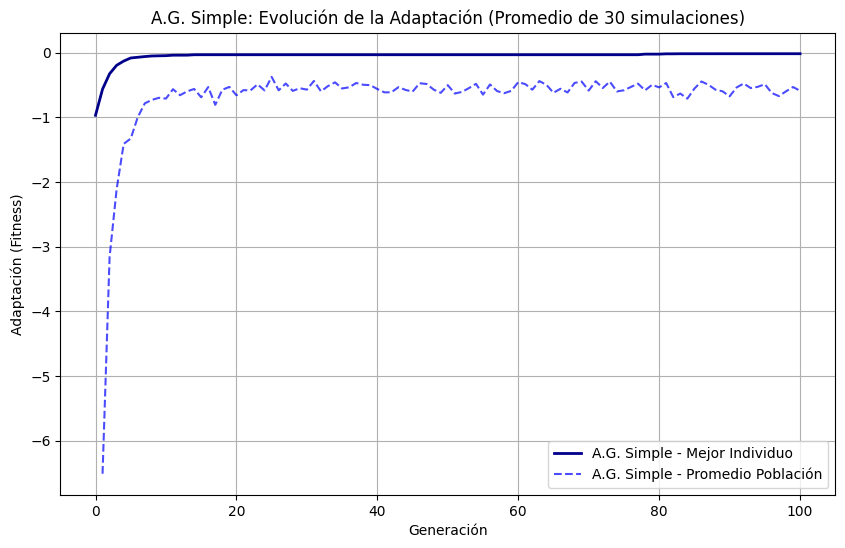

In [ ]:
print("Ejecutando A.G. Simple...")

simple_mejores_base, simple_promedios_base = ejecucion_simulacion(
    crossover_probability=0.7,
    mutation_probability=0.005
)

print("Simulaciones completadas exitosamente. Generando gráfica...")

gen_mejores_base = range(len(simple_mejores_base))
gen_promedios_base = range(1, len(simple_promedios_base) + 1)

plt.figure(figsize=(10, 6))
plt.plot(gen_mejores_base, simple_mejores_base, label='A.G. Simple - Mejor Individuo', color='darkblue', linewidth=2)
plt.plot(gen_promedios_base, simple_promedios_base, label='A.G. Simple - Promedio Población', color='blue', linestyle='--', alpha=0.7)

plt.title('A.G. Simple: Evolución de la Adaptación (Promedio de 30 simulaciones)')
plt.xlabel('Generación')
plt.ylabel('Adaptación (Fitness)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Simulación AG modificado.

1/3 Ejecutando A.G. Simple (Para comparación)...
2/3 Ejecutando A.G. Modificado (Renormalización Lineal)...
3/3 Ejecutando A.G. Modificado (Renormalización por Ventana)...


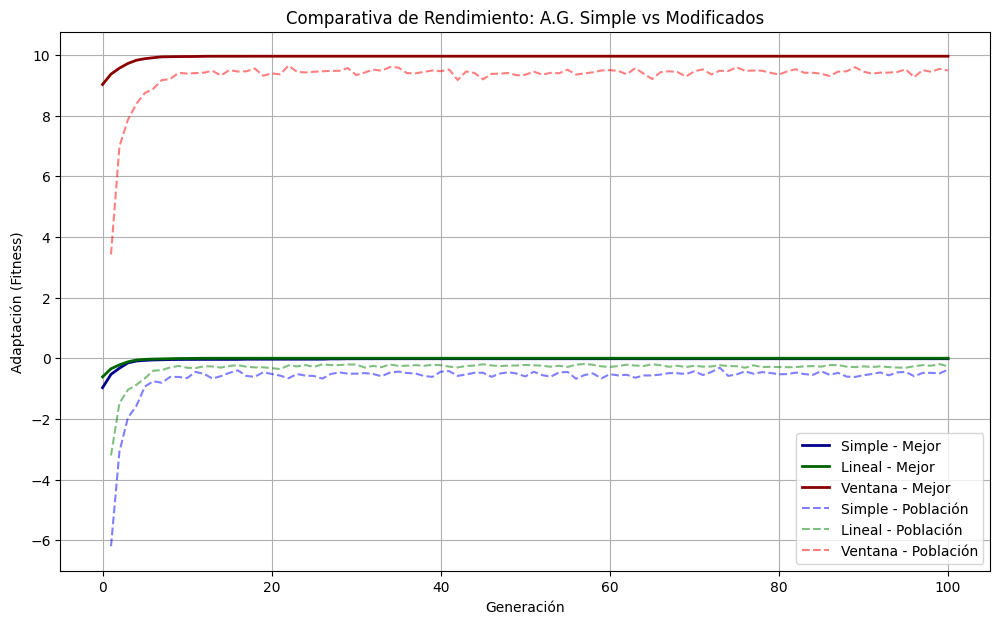

In [ ]:
MODO_ESCALADO = None

f_original = f

def f_con_escalado(x, y):
    valor_crudo = f_original(x, y)

    if MODO_ESCALADO is None:
        return valor_crudo

    if MODO_ESCALADO == "ventana":
        return valor_crudo - 10.0

    if MODO_ESCALADO == "lineal":
        return valor_crudo * 0.5

    return valor_crudo

f = f_con_escalado

print("1/3 Ejecutando A.G. Simple (Para comparación)...")
MODO_ESCALADO = None
simple_mejores, simple_promedios = ejecucion_simulacion(
    crossover_probability=0.7,
    mutation_probability=0.005
)

print("2/3 Ejecutando A.G. Modificado (Renormalización Lineal)...")
MODO_ESCALADO = "lineal"
lineal_mejores, lineal_promedios = ejecucion_simulacion(
    crossover_probability=0.7,
    mutation_probability=0.005
)

print("3/3 Ejecutando A.G. Modificado (Renormalización por Ventana)...")
MODO_ESCALADO = "ventana"
ventana_mejores, ventana_promedios = ejecucion_simulacion(
    crossover_probability=0.7,
    mutation_probability=0.005
)

f = f_original

gen_mejores = range(len(simple_mejores))
gen_promedios = range(1, len(simple_promedios) + 1)

plt.figure(figsize=(12, 7))

plt.plot(gen_mejores, simple_mejores, label='Simple - Mejor', color='darkblue', linewidth=2)
plt.plot(gen_mejores, lineal_mejores, label='Lineal - Mejor', color='darkgreen', linewidth=2)
plt.plot(gen_mejores, ventana_mejores, label='Ventana - Mejor', color='darkred', linewidth=2)

plt.plot(gen_promedios, simple_promedios, label='Simple - Población', color='blue', linestyle='--', alpha=0.5)
plt.plot(gen_promedios, lineal_promedios, label='Lineal - Población', color='green', linestyle='--', alpha=0.5)
plt.plot(gen_promedios, ventana_promedios, label='Ventana - Población', color='red', linestyle='--', alpha=0.5)

plt.title('Comparativa de Rendimiento: A.G. Simple vs Modificados')
plt.xlabel('Generación')
plt.ylabel('Adaptación (Fitness)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#Ultima parte

Iniciando barrido de parámetros cruzados...
Evaluando combinación -> P_C: 0.6 | P_M: 0.001
Evaluando combinación -> P_C: 0.6 | P_M: 0.005
Evaluando combinación -> P_C: 0.6 | P_M: 0.01
Evaluando combinación -> P_C: 0.75 | P_M: 0.001
Evaluando combinación -> P_C: 0.75 | P_M: 0.005
Evaluando combinación -> P_C: 0.75 | P_M: 0.01
Evaluando combinación -> P_C: 0.9 | P_M: 0.001
Evaluando combinación -> P_C: 0.9 | P_M: 0.005
Evaluando combinación -> P_C: 0.9 | P_M: 0.01

Barrido completado. Generando mapa de calor...


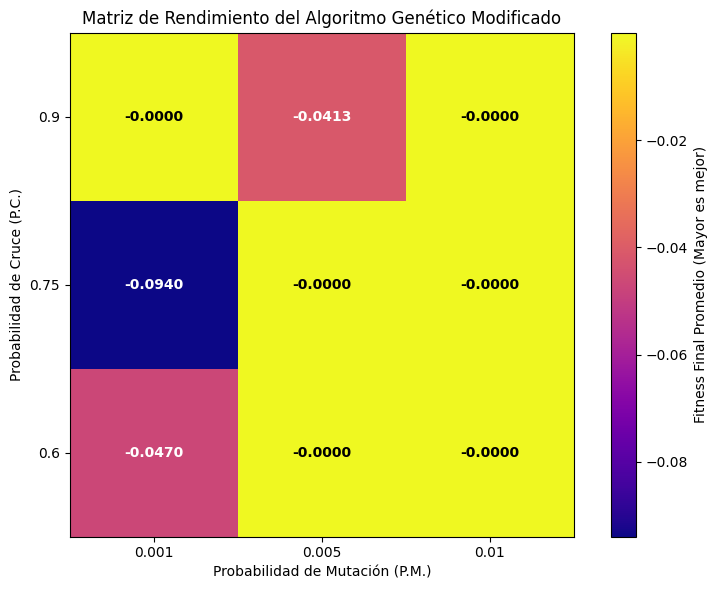

In [ ]:
valores_pc = [0.6, 0.75, 0.9]
valores_pm = [0.001, 0.005, 0.01]

matriz_rendimiento = np.zeros((len(valores_pc), len(valores_pm)))

print("Iniciando barrido de parámetros cruzados...")

for idx_pc, pc in enumerate(valores_pc):
    for idx_pm, pm in enumerate(valores_pm):
        print(f"Evaluando combinación -> P_C: {pc} | P_M: {pm}")

        mejores, _ = ejecucion_simulacion(
            numero_de_simulaciones=10,
            crossover_probability=pc,
            mutation_probability=pm
        )

        matriz_rendimiento[idx_pc, idx_pm] = mejores[-1]

print("\nBarrido completado. Generando mapa de calor...")

plt.figure(figsize=(8, 6))

plt.imshow(matriz_rendimiento, cmap='plasma', origin='lower')
plt.colorbar(label='Fitness Final Promedio (Mayor es mejor)')

plt.xticks(ticks=np.arange(len(valores_pm)), labels=valores_pm)
plt.yticks(ticks=np.arange(len(valores_pc)), labels=valores_pc)

plt.xlabel('Probabilidad de Mutación (P.M.)')
plt.ylabel('Probabilidad de Cruce (P.C.)')
plt.title('Matriz de Rendimiento del Algoritmo Genético Modificado')

for i in range(len(valores_pc)):
    for j in range(len(valores_pm)):
        val = matriz_rendimiento[i, j]
        color_texto = "white" if val < np.mean(matriz_rendimiento) else "black"
        plt.text(j, i, f"{val:.4f}", ha="center", va="center", color=color_texto, fontweight='bold')

plt.tight_layout()
plt.show()